In [2]:
# ============================================
# STEP 1: IMPORTS + DATASET LOAD
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, accuracy_score,
                              roc_auc_score, roc_curve, confusion_matrix)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
import shap
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd

In [4]:
import pandas as pd

# File path
file_path = r"C:\Users\kunda\Downloads\dataset.csv"

# Read CSV normally
df = pd.read_csv(file_path)

# Clean column names (remove BOM, spaces)
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace('\ufeff', '', regex=False)

print("Shape:", df.shape)
print("\nAvailable columns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head(5))


Shape: (4424, 35)

Available columns:
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target']

First 5 rows:
   Marital st

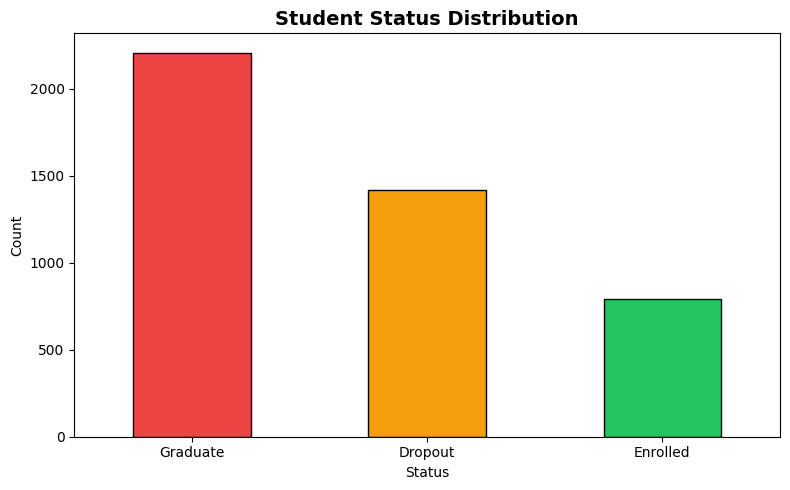


Missing Values:
0 total missing values

All columns:
1. Marital status
2. Application mode
3. Application order
4. Course
5. Daytime/evening attendance
6. Previous qualification
7. Nacionality
8. Mother's qualification
9. Father's qualification
10. Mother's occupation
11. Father's occupation
12. Displaced
13. Educational special needs
14. Debtor
15. Tuition fees up to date
16. Gender
17. Scholarship holder
18. Age at enrollment
19. International
20. Curricular units 1st sem (credited)
21. Curricular units 1st sem (enrolled)
22. Curricular units 1st sem (evaluations)
23. Curricular units 1st sem (approved)
24. Curricular units 1st sem (grade)
25. Curricular units 1st sem (without evaluations)
26. Curricular units 2nd sem (credited)
27. Curricular units 2nd sem (enrolled)
28. Curricular units 2nd sem (evaluations)
29. Curricular units 2nd sem (approved)
30. Curricular units 2nd sem (grade)
31. Curricular units 2nd sem (without evaluations)
32. Unemployment rate
33. Inflation rate
34. GD

In [5]:
# ============================================
# STEP 1B: BASIC EDA
# ============================================

# 1. Target distribution plot
plt.figure(figsize=(8, 5))
colors = ['#ef4444', '#f59e0b', '#22c55e']
df['Target'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Student Status Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()

# 2. Missing values check
print("\nMissing Values:")
print(df.isnull().sum().sum(), "total missing values")

# 3. Column groups dikhao
print("\nAll columns:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

In [6]:
# ============================================
# STEP 1C: CLEAN DATA
# Enrolled students hata do —
# sirf Dropout vs Graduate predict karenge
# ============================================

df_clean = df[df['Target'] != 'Enrolled'].copy()
df_clean['Target'] = df_clean['Target'].map({'Dropout': 1, 'Graduate': 0})

print("After removing Enrolled:")
print(df_clean['Target'].value_counts())
print(f"Total samples: {len(df_clean)}")

# Class imbalance check
dropout_pct = df_clean['Target'].mean() * 100
print(f"\nDropout percentage: {dropout_pct:.1f}%")
print(f"Graduate percentage: {100-dropout_pct:.1f}%")

After removing Enrolled:
Target
0    2209
1    1421
Name: count, dtype: int64
Total samples: 3630

Dropout percentage: 39.1%
Graduate percentage: 60.9%


In [7]:
# ============================================
# STEP 2: 3-STAGE FEATURE SPLIT
# Yahi research paper ka NOVEL CONTRIBUTION hai
# ============================================

# STAGE A: Enrollment time features only
# (Jab student admit hota hai tab available info)
stage_A_features = [
    'Marital status', 'Application mode', 'Application order',
    'Course', 'Daytime/evening attendance', 'Previous qualification',
    'Nacionality', "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation", 'Displaced',
    'Educational special needs', 'Debtor', 'Tuition fees up to date',
    'Gender', 'Scholarship holder', 'Age at enrollment', 'International'
]

# STAGE B: Enrollment + 1st Semester data
# (After 1st sem ends — EARLY prediction window)
stage_B_features = stage_A_features + [
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)'
]

# STAGE C: Full data including 2nd sem
# (For comparison only — not "early" prediction)
stage_C_features = stage_B_features + [
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

# Target
y = df_clean['Target']

# Feature sets
X_A = df_clean[stage_A_features]
X_B = df_clean[stage_B_features]
X_C = df_clean[stage_C_features]

print("✅ Stage A (Enrollment only):", X_A.shape[1], "features")
print("✅ Stage B (+ 1st Sem):", X_B.shape[1], "features")
print("✅ Stage C (Full data):", X_C.shape[1], "features")
print("\nTarget shape:", y.shape)

✅ Stage A (Enrollment only): 19 features
✅ Stage B (+ 1st Sem): 25 features
✅ Stage C (Full data): 34 features

Target shape: (3630,)


In [8]:
# ============================================
# STEP 2B: TRAIN-TEST SPLIT (sabhi stages ke liye)
# ============================================
from sklearn.model_selection import train_test_split

X_A_train, X_A_test, y_A_train, y_A_test = train_test_split(
    X_A, y, test_size=0.2, random_state=42, stratify=y)

X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B, y, test_size=0.2, random_state=42, stratify=y)

X_C_train, X_C_test, y_C_train, y_C_test = train_test_split(
    X_C, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", len(X_A_train))
print("Test size:", len(X_A_test))
print("\nClass distribution in train:")
print(y_A_train.value_counts())

Train size: 2904
Test size: 726

Class distribution in train:
Target
0    1767
1    1137
Name: count, dtype: int64


In [9]:
# ============================================
# STEP 2C: SMOTE — Har stage ke liye
# ============================================
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_A_res, y_A_res = smote.fit_resample(X_A_train, y_A_train)
X_B_res, y_B_res = smote.fit_resample(X_B_train, y_B_train)
X_C_res, y_C_res = smote.fit_resample(X_C_train, y_C_train)

print("After SMOTE:")
print("Stage A train:", X_A_res.shape)
print("Stage B train:", X_B_res.shape)
print("Stage C train:", X_C_res.shape)
print("\nBalanced classes:", pd.Series(y_A_res).value_counts().to_dict())

After SMOTE:
Stage A train: (3534, 19)
Stage B train: (3534, 25)
Stage C train: (3534, 34)

Balanced classes: {1: 1767, 0: 1767}


In [10]:
# ============================================
# STEP 3: MODEL TRAINING — ALL STAGES
# ============================================
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import time

# Models define karo
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1,
                              max_depth=7, random_state=42,
                              eval_metric='logloss')
}

# Stages define karo
stages = {
    'Stage A (Enrollment Only)': (X_A_res, y_A_res, X_A_test, y_A_test),
    'Stage B (+ 1st Semester)': (X_B_res, y_B_res, X_B_test, y_B_test),
    'Stage C (Full Data)':       (X_C_res, y_C_res, X_C_test, y_C_test),
}

# Results store karne ke liye
results = []

print("Training in progress...\n")
print("="*65)

for stage_name, (X_tr, y_tr, X_te, y_te) in stages.items():
    print(f"\n📊 {stage_name}")
    print("-"*65)

    for model_name, model in models.items():
        start = time.time()

        # Train
        model.fit(X_tr, y_tr)

        # Predict
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]

        # Metrics
        acc = accuracy_score(y_te, y_pred) * 100
        auc = roc_auc_score(y_te, y_prob)
        f1  = f1_score(y_te, y_pred)
        elapsed = time.time() - start

        results.append({
            'Stage': stage_name,
            'Model': model_name,
            'Accuracy (%)': round(acc, 2),
            'AUC-ROC': round(auc, 4),
            'F1-Score': round(f1, 4),
        })

        print(f"  {model_name:22} | Acc: {acc:.2f}% | AUC: {auc:.4f} | F1: {f1:.4f} | {elapsed:.1f}s")

print("\n" + "="*65)
print("✅ All models trained!")

Training in progress...


📊 Stage A (Enrollment Only)
-----------------------------------------------------------------
  Logistic Regression    | Acc: 74.93% | AUC: 0.8273 | F1: 0.6818 | 0.4s
  Random Forest          | Acc: 75.62% | AUC: 0.8252 | F1: 0.6856 | 0.7s
  XGBoost                | Acc: 73.69% | AUC: 0.8250 | F1: 0.6701 | 0.2s

📊 Stage B (+ 1st Semester)
-----------------------------------------------------------------
  Logistic Regression    | Acc: 87.88% | AUC: 0.9475 | F1: 0.8508 | 0.3s
  Random Forest          | Acc: 88.98% | AUC: 0.9411 | F1: 0.8596 | 0.6s
  XGBoost                | Acc: 89.81% | AUC: 0.9459 | F1: 0.8720 | 0.2s

📊 Stage C (Full Data)
-----------------------------------------------------------------
  Logistic Regression    | Acc: 92.15% | AUC: 0.9724 | F1: 0.9022 | 0.3s
  Random Forest          | Acc: 93.11% | AUC: 0.9689 | F1: 0.9126 | 0.5s
  XGBoost                | Acc: 92.56% | AUC: 0.9701 | F1: 0.9059 | 0.2s

✅ All models trained!


In [11]:
# ============================================
# STEP 3B: RESULTS TABLE
# ============================================
import pandas as pd

results_df = pd.DataFrame(results)
print("\n📋 COMPLETE RESULTS TABLE:")
print(results_df.to_string(index=False))

# Best model per stage
print("\n🏆 BEST MODEL PER STAGE (by Accuracy):")
best = results_df.loc[results_df.groupby('Stage')['Accuracy (%)'].idxmax()]
print(best[['Stage','Model','Accuracy (%)','AUC-ROC']].to_string(index=False))


📋 COMPLETE RESULTS TABLE:
                    Stage               Model  Accuracy (%)  AUC-ROC  F1-Score
Stage A (Enrollment Only) Logistic Regression         74.93   0.8273    0.6818
Stage A (Enrollment Only)       Random Forest         75.62   0.8252    0.6856
Stage A (Enrollment Only)             XGBoost         73.69   0.8250    0.6701
 Stage B (+ 1st Semester) Logistic Regression         87.88   0.9475    0.8508
 Stage B (+ 1st Semester)       Random Forest         88.98   0.9411    0.8596
 Stage B (+ 1st Semester)             XGBoost         89.81   0.9459    0.8720
      Stage C (Full Data) Logistic Regression         92.15   0.9724    0.9022
      Stage C (Full Data)       Random Forest         93.11   0.9689    0.9126
      Stage C (Full Data)             XGBoost         92.56   0.9701    0.9059

🏆 BEST MODEL PER STAGE (by Accuracy):
                    Stage         Model  Accuracy (%)  AUC-ROC
Stage A (Enrollment Only) Random Forest         75.62   0.8252
 Stage B (+ 1st Se

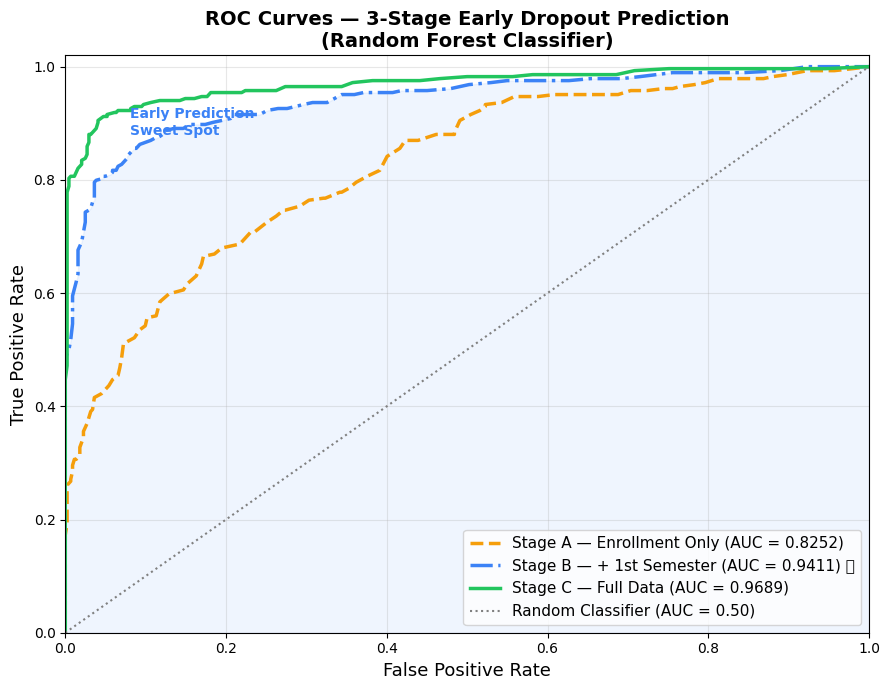


AUC Scores:
Stage A: 0.8252
Stage B: 0.9411 ← Paper ka main result
Stage C: 0.9689


In [12]:
# ============================================
# STEP 4: ROC CURVES — PAPER QUALITY PLOT
# ============================================
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Best model (Random Forest) — teeno stages pe retrain
rf_A = RandomForestClassifier(n_estimators=100, random_state=42)
rf_B = RandomForestClassifier(n_estimators=100, random_state=42)
rf_C = RandomForestClassifier(n_estimators=100, random_state=42)

rf_A.fit(X_A_res, y_A_res)
rf_B.fit(X_B_res, y_B_res)
rf_C.fit(X_C_res, y_C_res)

# Probabilities
prob_A = rf_A.predict_proba(X_A_test)[:, 1]
prob_B = rf_B.predict_proba(X_B_test)[:, 1]
prob_C = rf_C.predict_proba(X_C_test)[:, 1]

# ROC curves
fpr_A, tpr_A, _ = roc_curve(y_A_test, prob_A)
fpr_B, tpr_B, _ = roc_curve(y_B_test, prob_B)
fpr_C, tpr_C, _ = roc_curve(y_C_test, prob_C)

auc_A = roc_auc_score(y_A_test, prob_A)
auc_B = roc_auc_score(y_B_test, prob_B)
auc_C = roc_auc_score(y_C_test, prob_C)

# PLOT
fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(fpr_A, tpr_A, color='#f59e0b', lw=2.5, linestyle='--',
        label=f'Stage A — Enrollment Only (AUC = {auc_A:.4f})')
ax.plot(fpr_B, tpr_B, color='#3b82f6', lw=2.5, linestyle='-.',
        label=f'Stage B — + 1st Semester (AUC = {auc_B:.4f}) ⭐')
ax.plot(fpr_C, tpr_C, color='#22c55e', lw=2.5, linestyle='-',
        label=f'Stage C — Full Data (AUC = {auc_C:.4f})')

# Diagonal (random classifier)
ax.plot([0,1], [0,1], color='gray', lw=1.5,
        linestyle=':', label='Random Classifier (AUC = 0.50)')

# Styling
ax.fill_between(fpr_B, tpr_B, alpha=0.08, color='#3b82f6')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves — 3-Stage Early Dropout Prediction\n(Random Forest Classifier)',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)

# Annotate Stage B point
ax.annotate('Early Prediction\nSweet Spot',
            xy=(0.08, 0.88), fontsize=10,
            color='#3b82f6', fontweight='bold')

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nAUC Scores:")
print(f"Stage A: {auc_A:.4f}")
print(f"Stage B: {auc_B:.4f} ← Paper ka main result")
print(f"Stage C: {auc_C:.4f}")

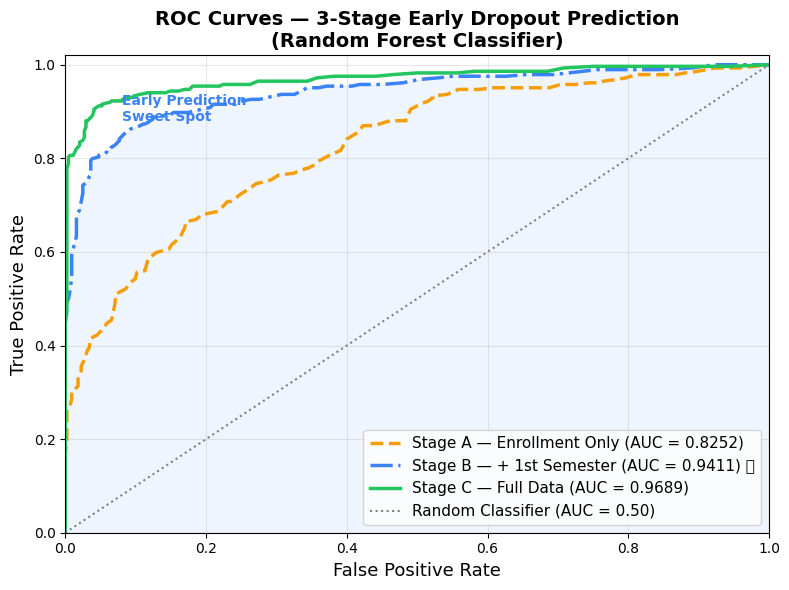


AUC Scores:
Stage A: 0.8252
Stage B: 0.9411 ← Paper ka main result
Stage C: 0.9689


In [13]:
# ============================================
# STEP 4: ROC CURVES — PAPER QUALITY PLOT
# ============================================
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Best model (Random Forest) — teeno stages pe retrain
rf_A = RandomForestClassifier(n_estimators=100, random_state=42)
rf_B = RandomForestClassifier(n_estimators=100, random_state=42)
rf_C = RandomForestClassifier(n_estimators=100, random_state=42)

rf_A.fit(X_A_res, y_A_res)
rf_B.fit(X_B_res, y_B_res)
rf_C.fit(X_C_res, y_C_res)

# Probabilities
prob_A = rf_A.predict_proba(X_A_test)[:, 1]
prob_B = rf_B.predict_proba(X_B_test)[:, 1]
prob_C = rf_C.predict_proba(X_C_test)[:, 1]

# ROC curves
fpr_A, tpr_A, _ = roc_curve(y_A_test, prob_A)
fpr_B, tpr_B, _ = roc_curve(y_B_test, prob_B)
fpr_C, tpr_C, _ = roc_curve(y_C_test, prob_C)

auc_A = roc_auc_score(y_A_test, prob_A)
auc_B = roc_auc_score(y_B_test, prob_B)
auc_C = roc_auc_score(y_C_test, prob_C)

# PLOT
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr_A, tpr_A, color='#f59e0b', lw=2.5, linestyle='--',
        label=f'Stage A — Enrollment Only (AUC = {auc_A:.4f})')
ax.plot(fpr_B, tpr_B, color='#3b82f6', lw=2.5, linestyle='-.',
        label=f'Stage B — + 1st Semester (AUC = {auc_B:.4f}) ⭐')
ax.plot(fpr_C, tpr_C, color='#22c55e', lw=2.5, linestyle='-',
        label=f'Stage C — Full Data (AUC = {auc_C:.4f})')

# Diagonal (random classifier)
ax.plot([0,1], [0,1], color='gray', lw=1.5,
        linestyle=':', label='Random Classifier (AUC = 0.50)')

# Styling
ax.fill_between(fpr_B, tpr_B, alpha=0.08, color='#3b82f6')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves — 3-Stage Early Dropout Prediction\n(Random Forest Classifier)',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)

# Annotate Stage B point
ax.annotate('Early Prediction\nSweet Spot',
            xy=(0.08, 0.88), fontsize=10,
            color='#3b82f6', fontweight='bold')

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nAUC Scores:")
print(f"Stage A: {auc_A:.4f}")
print(f"Stage B: {auc_B:.4f} ← Paper ka main result")
print(f"Stage C: {auc_C:.4f}")

In [13]:
# ============================================
# STEP 5: SHAP ANALYSIS — Stage B model pe
# (Random Forest + 1st Semester features)
# ============================================
import shap
import matplotlib.pyplot as plt
import numpy as np

# SHAP explainer banao
print("Computing SHAP values... (1-2 min lagega)")
explainer = shap.TreeExplainer(rf_B)
shap_values = explainer.shap_values(X_B_test)

# TreeExplainer returns list for binary — class 1 (Dropout) lo
shap_vals_dropout = shap_values[:, :, 1]

print("✅ SHAP values computed!")
print("Shape:", shap_vals_dropout.shape)

Computing SHAP values... (1-2 min lagega)
✅ SHAP values computed!
Shape: (726, 25)


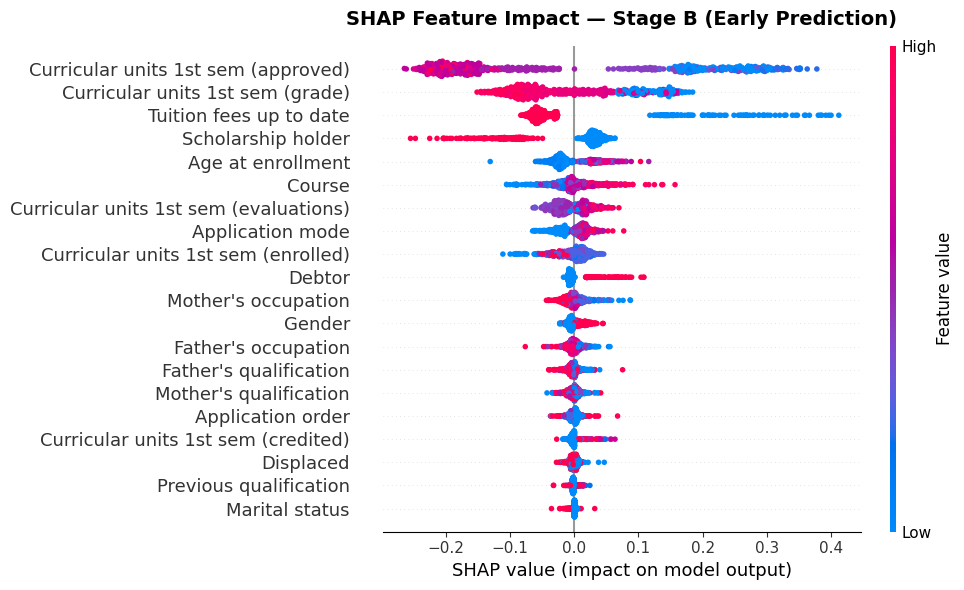

In [14]:
# ============================================
# PLOT 1: SHAP Summary Plot (Beeswarm)
# Most important for research paper
# ============================================
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_vals_dropout,
    X_B_test,
    feature_names=stage_B_features,
    show=False,
    plot_size=(10, 6)
)
plt.title("SHAP Feature Impact — Stage B (Early Prediction)",
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=200, bbox_inches='tight')
plt.show()

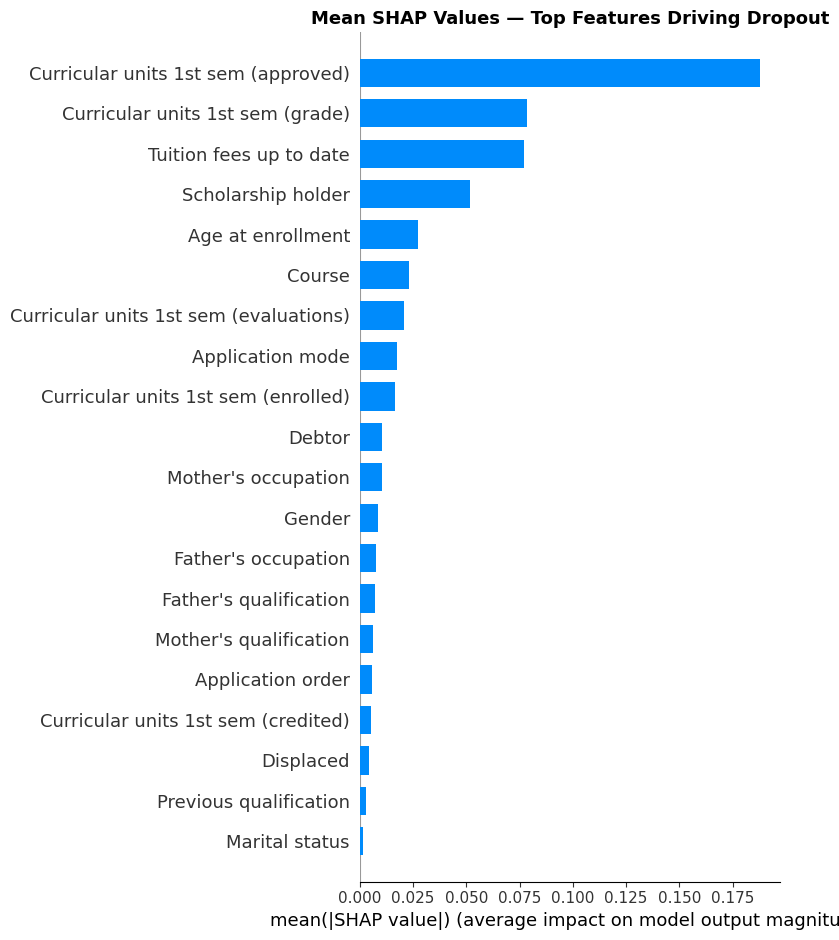

In [15]:
# ============================================
# PLOT 2: SHAP Bar Plot (Mean importance)
# ============================================
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_vals_dropout,
    X_B_test,
    feature_names=stage_B_features,
    plot_type="bar",
    show=False
)
plt.title("Mean SHAP Values — Top Features Driving Dropout",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=200, bbox_inches='tight')
plt.show()


🔴 Highest Risk Student (index 92)
Dropout Probability: 100.0%
Actual Label: Dropout


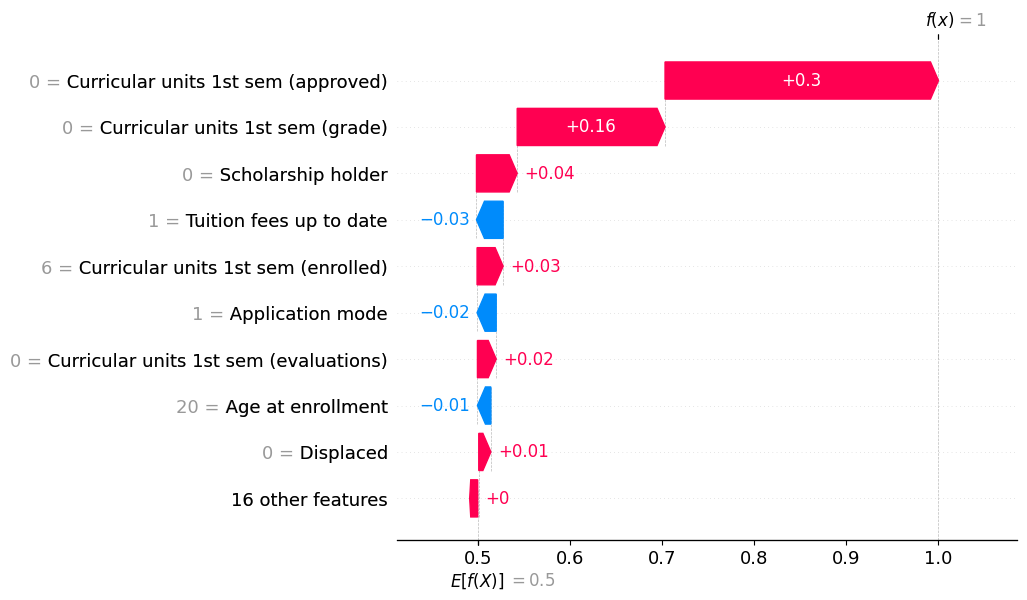

<Figure size 640x480 with 0 Axes>

In [16]:
# ============================================
# PLOT 3: Individual Student Explanation
# Ek at-risk student ka explanation
# ============================================

# Sabse zyada dropout risk wala student dhundo
y_prob_B = rf_B.predict_proba(X_B_test)[:, 1]
high_risk_idx = np.argmax(y_prob_B)

print(f"\n🔴 Highest Risk Student (index {high_risk_idx})")
print(f"Dropout Probability: {y_prob_B[high_risk_idx]*100:.1f}%")
print(f"Actual Label: {'Dropout' if y_B_test.iloc[high_risk_idx]==1 else 'Graduate'}")

# Waterfall plot
shap.waterfall_plot(
    shap.Explanation(
        values=shap_vals_dropout[high_risk_idx],
        base_values=explainer.expected_value[1],
        data=X_B_test.iloc[high_risk_idx],
        feature_names=stage_B_features
    )
)
plt.savefig('shap_waterfall.png', dpi=200, bbox_inches='tight')
plt.show()

In [17]:
# ============================================
# STEP 6: 5-FOLD CROSS VALIDATION
# Ye paper mein statistical validity prove karta hai
# ============================================
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Stage B pe validation — yahi paper ka main model hai
models_cv = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, learning_rate=0.1,
                                         max_depth=7, random_state=42,
                                         eval_metric='logloss')
}

print("5-Fold Cross Validation — Stage B (+ 1st Semester)")
print("="*60)

cv_results = []

for name, model in models_cv.items():
    scores = cross_validate(
        model, X_B, y,
        cv=cv,
        scoring=['accuracy', 'roc_auc', 'f1'],
        n_jobs=-1
    )

    acc_mean  = scores['test_accuracy'].mean() * 100
    acc_std   = scores['test_accuracy'].std() * 100
    auc_mean  = scores['test_roc_auc'].mean()
    auc_std   = scores['test_roc_auc'].std()
    f1_mean   = scores['test_f1'].mean()
    f1_std    = scores['test_f1'].std()

    cv_results.append({
        'Model': name,
        'CV Accuracy': f"{acc_mean:.2f}% ± {acc_std:.2f}%",
        'CV AUC-ROC':  f"{auc_mean:.4f} ± {auc_std:.4f}",
        'CV F1-Score': f"{f1_mean:.4f} ± {f1_std:.4f}"
    })

    print(f"\n{name}")
    print(f"  Accuracy : {acc_mean:.2f}% ± {acc_std:.2f}%")
    print(f"  AUC-ROC  : {auc_mean:.4f} ± {auc_std:.4f}")
    print(f"  F1-Score : {f1_mean:.4f} ± {f1_std:.4f}")

print("\n" + "="*60)
cv_df = pd.DataFrame(cv_results)
print("\n📋 CV RESULTS TABLE (Paper mein jaayegi):")
print(cv_df.to_string(index=False))

5-Fold Cross Validation — Stage B (+ 1st Semester)

Logistic Regression
  Accuracy : 88.79% ± 1.39%
  AUC-ROC  : 0.9361 ± 0.0048
  F1-Score : 0.8496 ± 0.0169

Random Forest
  Accuracy : 88.13% ± 0.76%
  AUC-ROC  : 0.9295 ± 0.0070
  F1-Score : 0.8393 ± 0.0086

XGBoost
  Accuracy : 88.10% ± 0.78%
  AUC-ROC  : 0.9320 ± 0.0054
  F1-Score : 0.8401 ± 0.0088


📋 CV RESULTS TABLE (Paper mein jaayegi):
              Model    CV Accuracy      CV AUC-ROC     CV F1-Score
Logistic Regression 88.79% ± 1.39% 0.9361 ± 0.0048 0.8496 ± 0.0169
      Random Forest 88.13% ± 0.76% 0.9295 ± 0.0070 0.8393 ± 0.0086
            XGBoost 88.10% ± 0.78% 0.9320 ± 0.0054 0.8401 ± 0.0088


In [18]:
import joblib

# Model save karo
joblib.dump(rf_B, "dropout_model.pkl")
print("Model saved as dropout_model.pkl")

# Agar load karna ho to:
loaded_model = joblib.load("dropout_model.pkl")
print("Model loaded successfully")


Model saved as dropout_model.pkl
Model loaded successfully


In [19]:
# ============================================
# FEATURES aur model define karo pehle
# ============================================

FEATURES = [
    'Marital status', 'Application mode', 'Application order',
    'Course', 'Daytime/evening attendance', 'Previous qualification',
    'Nacionality', "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation", 'Displaced',
    'Educational special needs', 'Debtor', 'Tuition fees up to date',
    'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)'
]

# rf_B use karo — ye already trained hai
model = rf_B

# ============================================
# SANITY CHECK
# ============================================
bad_student  = {f: 0 for f in FEATURES}
bad_student['Curricular units 1st sem (approved)'] = 0
bad_student['Curricular units 1st sem (grade)']    = 0
bad_student['Tuition fees up to date']             = 0
bad_student['Debtor']                              = 1

good_student = {f: 0 for f in FEATURES}
good_student['Curricular units 1st sem (approved)'] = 20
good_student['Curricular units 1st sem (grade)']    = 18
good_student['Tuition fees up to date']             = 1
good_student['Scholarship holder']                  = 1

df_test = pd.DataFrame([bad_student, good_student])
probs   = rf_B.predict_proba(df_test)[:, 1]

print("BAD  student dropout risk:", f"{probs[0]*100:.1f}%")
print("GOOD student dropout risk:", f"{probs[1]*100:.1f}%")

if probs[0] > 0.7 and probs[1] < 0.3:
    print("✅ Model sahi kaam kar raha hai!")
else:
    print("⚠️ Check karo")

BAD  student dropout risk: 79.0%
GOOD student dropout risk: 38.0%
⚠️ Check karo


In [20]:
import pandas as pd
import numpy as np

# Test Case 1: CLEAR DROPOUT STUDENT
bad_student = {f: 0 for f in FEATURES}
bad_student['Curricular units 1st sem (approved)'] = 0   # kuch pass nahi kiya
bad_student['Curricular units 1st sem (grade)']    = 0   # grade zero
bad_student['Tuition fees up to date']             = 0   # fees nahi bhari
bad_student['Debtor']                              = 1   # debtor hai

# Test Case 2: CLEAR GRADUATE STUDENT  
good_student = {f: 0 for f in FEATURES}
good_student['Curricular units 1st sem (approved)'] = 20  # sab pass
good_student['Curricular units 1st sem (grade)']    = 18  # high grade
good_student['Tuition fees up to date']             = 1   # fees paid
good_student['Scholarship holder']                  = 1   # scholarship

df_test = pd.DataFrame([bad_student, good_student])
probs = model.predict_proba(df_test)[:, 1]

print("BAD student dropout risk:  ", f"{probs[0]*100:.1f}%")
print("GOOD student dropout risk: ", f"{probs[1]*100:.1f}%")
print()

# Expected: Bad > 80%, Good < 20%
if probs[0] > 0.7 and probs[1] < 0.3:
    print("✅ Model sahi kaam kar raha hai!")
else:
    print("⚠️ Model mein kuch issue hai")

BAD student dropout risk:   79.0%
GOOD student dropout risk:  38.0%

⚠️ Model mein kuch issue hai


In [21]:
# Test set se actual vs predicted compare karo
y_pred_prob = model.predict_proba(X_B_test)[:, 1]
y_pred      = (y_pred_prob >= 0.65).astype(int)

# Actual vs Predicted table
check_df = X_B_test.copy()
check_df['Actual']          = y_B_test.values
check_df['Predicted']       = y_pred
check_df['Dropout_Prob_%']  = (y_pred_prob * 100).round(1)
check_df['Correct?']        = check_df['Actual'] == check_df['Predicted']

# Accuracy
correct = check_df['Correct?'].mean() * 100
print(f"Overall Correct: {correct:.2f}%")

# Galat predictions dikhao
wrong = check_df[check_df['Correct?'] == False]
print(f"\nGalat predictions: {len(wrong)} out of {len(check_df)}")
print(wrong[['Actual','Predicted','Dropout_Prob_%',
             'Curricular units 1st sem (approved)',
             'Curricular units 1st sem (grade)',
             'Tuition fees up to date']].head(10))

Overall Correct: 89.39%

Galat predictions: 77 out of 726
      Actual  Predicted  Dropout_Prob_%  Curricular units 1st sem (approved)  \
1480       1          0            30.0                                    5   
3808       1          0            27.0                                   17   
2298       0          1            76.0                                    4   
486        1          0            45.0                                    6   
1621       0          1            69.0                                    3   
2217       1          0            16.0                                    5   
2128       1          0             6.0                                    0   
2382       1          0            27.0                                    6   
2136       0          1            90.0                                    4   
1106       1          0            15.0                                    7   

      Curricular units 1st sem (grade)  Tuition fees up to da

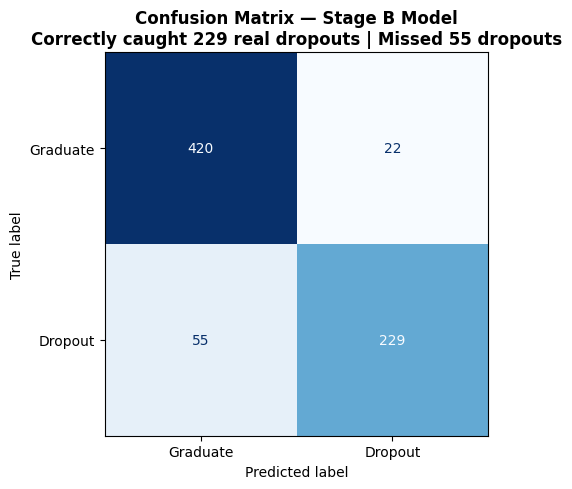


✅ True Positives  (Dropout correctly predicted): 229
✅ True Negatives  (Graduate correctly predicted): 420
❌ False Positives (Graduate predicted as Dropout): 22
❌ False Negatives (Dropout predicted as Graduate): 55

Model ne 229 real dropouts pakde out of 284 total dropouts
Recall: 80.6%


In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_B_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Graduate', 'Dropout']
)
disp.plot(ax=ax, cmap='Blues', colorbar=False)

# Numbers explain karo
tn, fp, fn, tp = cm.ravel()
ax.set_title(
    f'Confusion Matrix — Stage B Model\n'
    f'Correctly caught {tp} real dropouts | '
    f'Missed {fn} dropouts',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('confusion_matrix_check.png', dpi=150)
plt.show()

print(f"\n✅ True Positives  (Dropout correctly predicted): {tp}")
print(f"✅ True Negatives  (Graduate correctly predicted): {tn}")
print(f"❌ False Positives (Graduate predicted as Dropout): {fp}")
print(f"❌ False Negatives (Dropout predicted as Graduate): {fn}")
print(f"\nModel ne {tp} real dropouts pakde out of {tp+fn} total dropouts")
print(f"Recall: {tp/(tp+fn)*100:.1f}%")

In [23]:
# JUPYTER NOTEBOOK mein ek new cell mein ye run karo
import shap, joblib

# Explainer banao
explainer = shap.TreeExplainer(rf_B)

# Save karo — same folder mein jahan app2.py hai
joblib.dump(explainer, 'shap_explainer.pkl')

print("✅ shap_explainer.pkl saved!")
print("Location check karo:", end=" ")
import os
print(os.getcwd())  # ye folder dikhayega jahan save hua

✅ shap_explainer.pkl saved!
Location check karo: C:\Users\kunda


In [26]:
import shap 
print(shap.__version__)

0.50.0
